# LeetCode #120: Triangle

https://leetcode.com/problems/triangle/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Recursion (naive) | O(2^n) | O(n) | Exponential, TLE |
| Top-down DP (memoization) | O(n²) | O(n²) | Extra memo table |
| **Bottom-up DP (1D array)** | **O(n²)** | **O(n)** | **Optimal — in-place, single pass** |

## Understanding the Method

Start from the bottom row of the triangle and work upward. At each cell, the minimum cost is:
`dp[j] = triangle[row][j] + min(dp[j], dp[j+1])`
where `dp[j]` and `dp[j+1]` are already computed minimum paths from the row below.

## Constraints

- `1 <= triangle.length <= 200`
- `triangle[0].length == 1`
- `triangle[i].length == triangle[i-1].length + 1`
- `-10^4 <= triangle[i][j] <= 10^4`

## Solutions

### C#

In [ ]:
public class Solution {
    public int MinimumTotal(IList<IList<int>> triangle) {
        int n = triangle.Count;
        int[] dp = new int[n];
        for (int j = 0; j < n; j++) dp[j] = triangle[n-1][j];
        for (int i = n - 2; i >= 0; i--)
            for (int j = 0; j <= i; j++)
                dp[j] = triangle[i][j] + Math.Min(dp[j], dp[j+1]);
        return dp[0];
    }
}

### Python

In [ ]:
class Solution:
    def minimumTotal(self, triangle: list[list[int]]) -> int:
        dp = triangle[-1][:]
        for i in range(len(triangle) - 2, -1, -1):
            for j in range(len(triangle[i])):
                dp[j] = triangle[i][j] + min(dp[j], dp[j+1])
        return dp[0]

### Go

In [ ]:
func minimumTotal(triangle [][]int) int {
    n := len(triangle)
    dp := make([]int, n)
    copy(dp, triangle[n-1])
    for i := n - 2; i >= 0; i-- {
        for j := 0; j <= i; j++ {
            if dp[j+1] < dp[j] {
                dp[j] = triangle[i][j] + dp[j+1]
            } else {
                dp[j] = triangle[i][j] + dp[j]
            }
        }
    }
    return dp[0]
}

### Rust

In [ ]:
impl Solution {
    pub fn minimum_total(triangle: Vec<Vec<i32>>) -> i32 {
        let n = triangle.len();
        let mut dp = triangle[n-1].clone();
        for i in (0..n-1).rev() {
            for j in 0..=i {
                dp[j] = triangle[i][j] + dp[j].min(dp[j+1]);
            }
        }
        dp[0]
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]`  
Start with bottom row as `dp = [4,1,8,3]`. Work upward: `dp[j] = triangle[i][j] + min(dp[j], dp[j+1])`. After row 2: `dp = [7,6,10]`. After row 1: `dp = [9,10]`. After row 0: `dp = [11]`.  
WHY tricky: Demonstrates the standard bottom-up flow. Path $2 \to 3 \to 5 \to 1 = 11$. LaTeX: $dp[j] = T[i][j] + \min(dp[j],\, dp[j{+}1])$.

### 2. Slightly Complex -- Negative Values
**Input:** `triangle = [[-1],[2,3],[1,-1,-3]]`  
Negatives make greedy top-down fail. Init `dp = [1,-1,-3]`. Row 1: `dp = [1,0]`. Row 0: `dp = [-1]`. Optimal path: $-1 \to 3 \to (-3) = -1$.  
WHY tricky: Greedy picks 2 (smaller than 3) at row 1, but optimal goes through 3 to reach $-3$. DP handles this correctly. LaTeX: $\text{path} = -1 + 3 + (-3) = -1$.

### 3. Edge Case: Time Factor
**Input:** Triangle with $n = 200$ rows, all values $= 1$ (total cells $= \frac{200 \times 201}{2} = 20{,}100$)  
Bottom-up DP processes each cell once. Total operations $= \frac{n(n+1)}{2} = 20{,}100$, each $O(1)$. Naive recursion: $O(2^n) = O(2^{200})$.  
WHY tricky: DP eliminates overlapping subproblems, reducing exponential to $O(n^2)$. LaTeX: $O\bigl(\frac{n(n+1)}{2}\bigr) \approx O(n^2)$.

### 4. Edge Case: Space Factor
**Input:** Triangle with $n = 200$ rows, values in $[-10000, 10000]$  
Full 2D DP stores $20{,}100$ integers. 1D optimization uses a single array of length $n = 200$. Processing left-to-right: `dp[j]` is overwritten only after `dp[j+1]` is read.  
WHY tricky: The follow-up asks for $O(n)$ space. Key insight: in-place update order preserves needed values. LaTeX: $O(n^2) \to O(n)$, a $99.5\%$ reduction.

### 5. Almost-Impossible but Plausible
**Input:** Triangle with $n = 200$ rows, every value $= -10000$  
Every path has 200 elements. Min sum $= 200 \times (-10000) = -2{,}000{,}000$. Fits in 32-bit int (min: $-2{,}147{,}483{,}648$). All paths give identical sums.  
WHY tricky: Max negative accumulation at boundary constraints. $200 \times (-10^4) = -2 \times 10^6$, safe from overflow. LaTeX: $|\text{sum}| = 2 \times 10^6 < 2^{31} \approx 2.1 \times 10^9$.

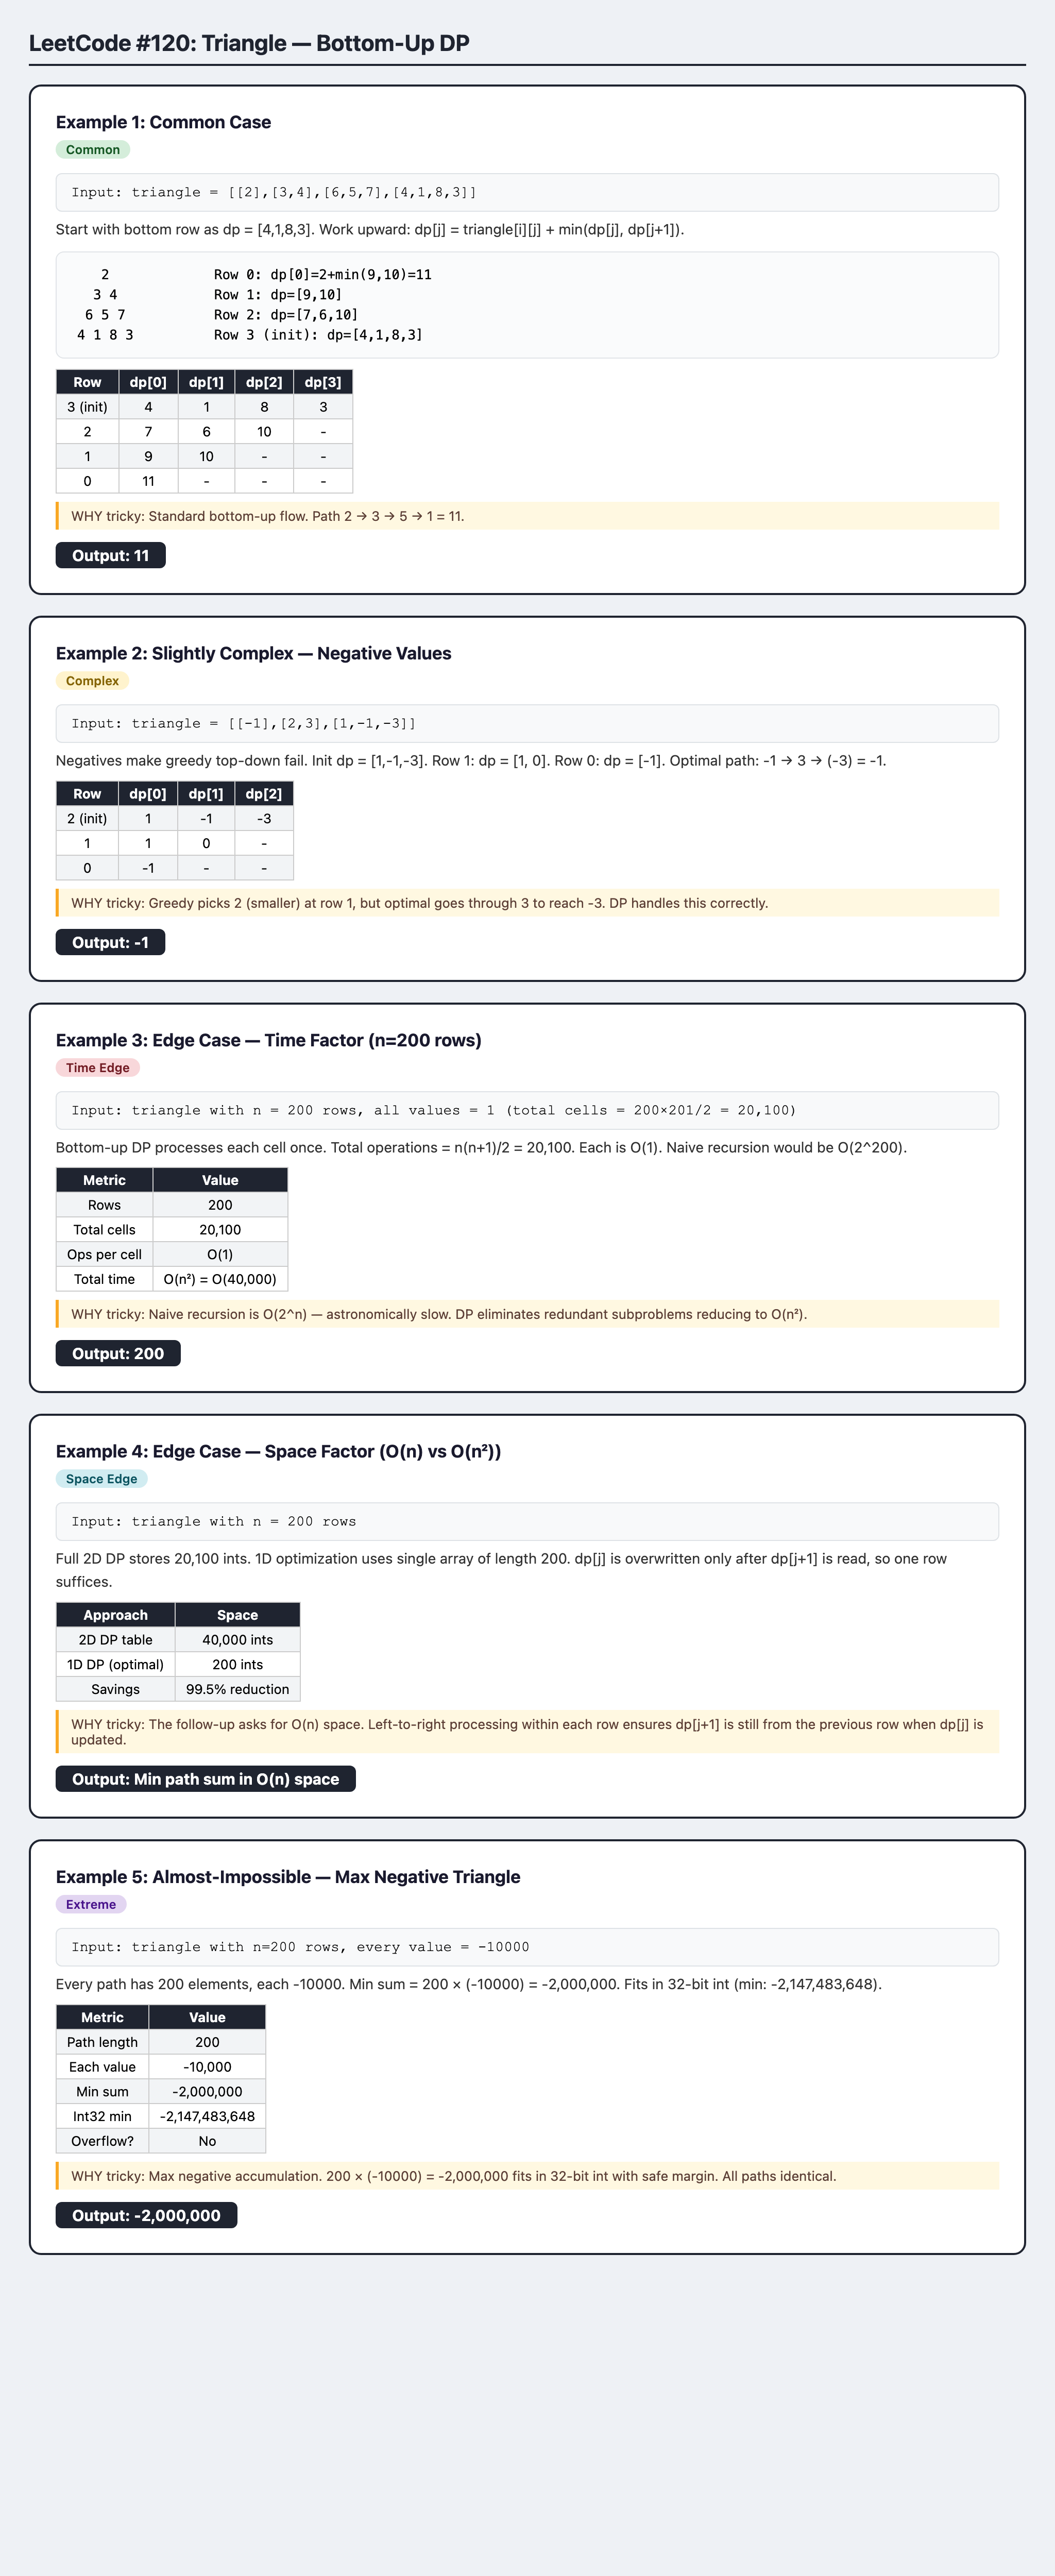